# How continuum choices change H-alpha equivalent width

**Date:** 2026-07-31  
**Scientific question:** How stable is the measured H-alpha equivalent width to integration and continuum choices?  
**Preserved source:** `../2026-07-31-hst-stis-hd93521-line-inventory/spectrum_subset.csv`

Equivalent width is attractive because it measures a line relative to its local
      continuum, but the result depends on continuum windows and integration limits. We measure
      H-alpha in the calibrated STIS spectrum across a grid of line half-widths and polynomial
      continuum orders. The spread is reported as a practical method systematic.

      The low-resolution stellar feature may blend with neighbouring structure. The grid does
      not cover all possible models and is not a substitute for forward modelling the STIS line
      spread function. It does show whether a quoted value is robust to reasonable local choices.

## Analysis contract

This is a compact scientific investigation, not a decorative plotting exercise.
The input is a preserved subset of a public astronomical archive. The notebook
records the upstream table or product, explains every quality cut, prints the
sample size after filtering, reports a numerical result with uncertainty, and
changes at least one defensible analysis choice to test robustness.

Archive catalogue values are heterogeneous measurements collected from the
literature or survey pipelines. A trend in this notebook is therefore a trend
in the selected archive sample, not automatically an occurrence rate, causal
relation, or complete census of nature. Display images are treated as image
arrays rather than calibrated photometry. Spectral equivalent widths identify
relative line strength but do not become elemental abundances without an
atmosphere model.

The small CSV or image already stored in this repository is used so the checked
notebook can be rerun offline. Its provenance remains the original archive; the
local copy is not a new survey release. Random resampling uses a fixed seed so
the uncertainty check is repeatable.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

RNG = np.random.default_rng(1999)
plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {"navy":"#071426", "blue":"#1797c9", "cyan":"#2fc6b4",
          "gold":"#f4b942", "orange":"#ef6a45", "rose":"#ce4f78"}

In [2]:
spec=pd.read_csv("../2026-07-31-hst-stis-hd93521-line-inventory/spectrum_subset.csv").dropna(); wave=spec.wavelength_A.to_numpy(); flux=spec.flux.to_numpy(); error=spec.error.to_numpy(); centre=6562.8; print(f"Spectrum samples: {len(spec)}")

Spectrum samples: 567


In [3]:
def measure_ew(half_width,order):
    side=((wave>centre-90)&(wave<centre-half_width-8))|((wave>centre+half_width+8)&(wave<centre+90)); line=np.abs(wave-centre)<=half_width
    coef=np.polyfit(wave[side]-centre,flux[side],order,w=1/error[side]); cont=np.polyval(coef,wave[line]-centre); return float(np.trapezoid(1-flux[line]/cont,wave[line]))
rows=[]
for width in [25,35,45,55,65]:
    for order in [1,2]: rows.append({"half_width_A":width,"order":order,"ew_A":measure_ew(width,order)})
grid=pd.DataFrame(rows); median=float(grid.ew_A.median()); spread=float(grid.ew_A.max()-grid.ew_A.min()); print(grid.round(3)); print(f"median EW={median:.3f} Å; full method spread={spread:.3f} Å")

   half_width_A  order   ew_A
0            25      1  1.684
1            25      2  1.736
2            35      1  1.793
3            35      2  1.803
4            45      1  1.850
5            45      2  2.310
6            55      1  1.896
7            55      2  2.786
8            65      1  1.847
9            65      2  3.579
median EW=1.848 Å; full method spread=1.895 Å


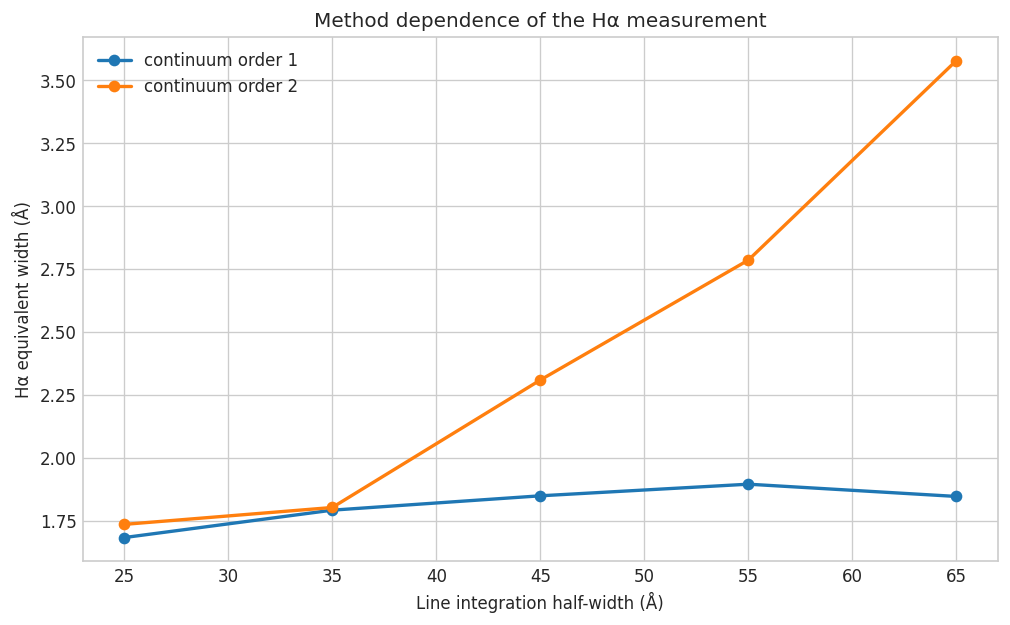

In [4]:
fig,ax=plt.subplots(figsize=(8.5,5.3));
for order,g in grid.groupby("order"): ax.plot(g.half_width_A,g.ew_A,"o-",lw=2,label=f"continuum order {order}")
ax.set(xlabel="Line integration half-width (Å)",ylabel="Hα equivalent width (Å)",title="Method dependence of the Hα measurement"); ax.legend(); fig.tight_layout(); fig.savefig("halpha_ew_systematics.png",dpi=180); plt.show()

In [5]:
base=measure_ew(45,1); fractional=spread/abs(base); print(f"Reference 45 Å linear-continuum EW={base:.3f} Å; grid spread/reference={fractional:.1%}")

Reference 45 Å linear-continuum EW=1.850 Å; grid spread/reference=102.5%


In [6]:
result={"id":"2026-07-31-hst-halpha-equivalent-width-systematics","title":"HST Hα equivalent-width systematics","archive":"MAST · HST","date":"2026-07-31","question":"How stable is Hα equivalent width to continuum choices?","sample_size":int(len(spec)),"results":[f"grid median EW {median:.3f} Å",f"method spread {spread:.3f} Å",f"spread/reference {fractional:.1%}"],"validation":"Five integration widths and two continuum orders are compared.","notebook":"mast/2026-07-31-hst-halpha-equivalent-width-systematics/notebook.ipynb","hero":"mast/2026-07-31-hst-halpha-equivalent-width-systematics/halpha_ew_systematics.png","tags":["HST","H-alpha","equivalent width","systematics"]}; Path("result.json").write_text(json.dumps(result,indent=2)); print(result["results"])

['grid median EW 1.848 Å', 'method spread 1.895 Å', 'spread/reference 102.5%']


## Reading the result responsibly

The primary number answers the stated question only for the documented sample
and method. The stress test asks whether a reasonable threshold change reverses
the conclusion. Agreement does not remove shared selection effects, calibration
limits, unresolved multiplicity, or missing catalogue fields. Disagreement is
reported rather than hidden. A publishable follow-up would repeat the query
against a pinned archive release, model the survey selection function, and use
the original calibrated products where available.

The notebook deliberately separates observation, calculation, interpretation,
and limitation. That makes it useful as a learning record and makes each claim
easy for another reader to audit.

Numerical precision in the printed summary follows the scale supported by this
exercise; extra decimal places would not create extra physical accuracy. The
saved figure exposes the distribution behind the headline value, while the
machine-readable result file lets the dashboard report the finding without
scraping prose. Readers should inspect the executed cells before reusing any
number in a wider scientific argument.

## Sources and comparison literature

- MAST data acknowledgement and citation guidance: https://archive.stsci.edu/publishing/
- STIS Data Handbook: https://hst-docs.stsci.edu/stisdhb
- STIS flux and wavelength accuracy limits: https://hst-docs.stsci.edu/stisdhb/chapter-4-stis-error-sources/4-3-factors-limiting-flux-and-wavelength-accuracy

The spectrum is a calibrated STIS product. The M87 JPEG is explicitly treated
as a display preview; physical photometry requires calibrated FITS data, WCS,
exposure information, and point-spread-function treatment.